<a href="https://colab.research.google.com/github/mariacastrom00/AI_exercises_MJCM/blob/main/Exercise_2_regression_model/Assignment_1_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) To predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [79]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [80]:
df.shape

(17379, 17)

In [81]:
df.info()
# atemp: Vad det känns som
# casual: Count of casual users
# cnt: Total amount of bycicles

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

<Axes: xlabel='cnt', ylabel='Count'>

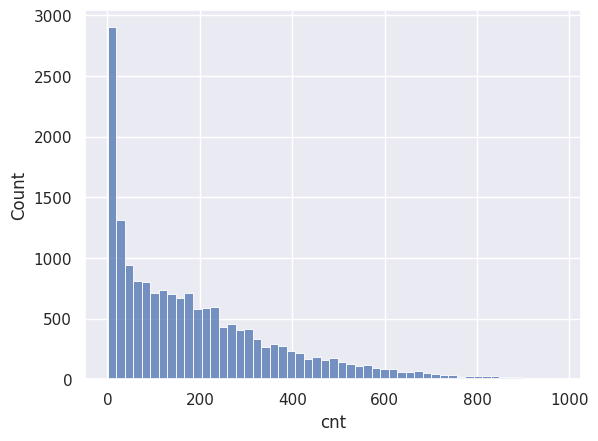

In [82]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

sns.histplot(x=df['cnt'])

In [83]:
df.drop(columns=['dteday'], inplace=True)

In [84]:
corr_matrix = df.corr()
corr_matrix['cnt'].sort_values(ascending=False)

,cnt
cnt,1.000000
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hr,0.394071
instant,0.278379
yr,0.250495
season,0.178056
mnth,0.120638


In [85]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [86]:
# CHOOSE THE FIRST!!!!

# What: instant, casual, registered, atemp. Why: atemp felt like a combination of windspeed+temp+wheathersit (redundant), instant felt unncessesary (observation identifier), casual and registered was the sum of cnt so it felt like overflowing of information (prevent target leakage).
# Score: 0.5125658834406476
# X.drop(columns=['instant', 'casual', 'registered', 'atemp'], inplace=True)

# What: workingday, weekday, holiday. Why: When doing the correlation matrix, these had the lowest values
# Score: 0.9999929869773514
# Feels bad? Too god to be true...
# X.drop(columns=['workingday', 'weekday', 'holiday', 'atemp'], inplace=True)

# What: workingday, weekday, holiday. Why: When doing the correlation matrix, these had the lowest values
# Score: 0.5258824754737466
X.drop(columns=['workingday', 'weekday', 'holiday', 'atemp', 'casual', 'registered', 'instant'], inplace=True)


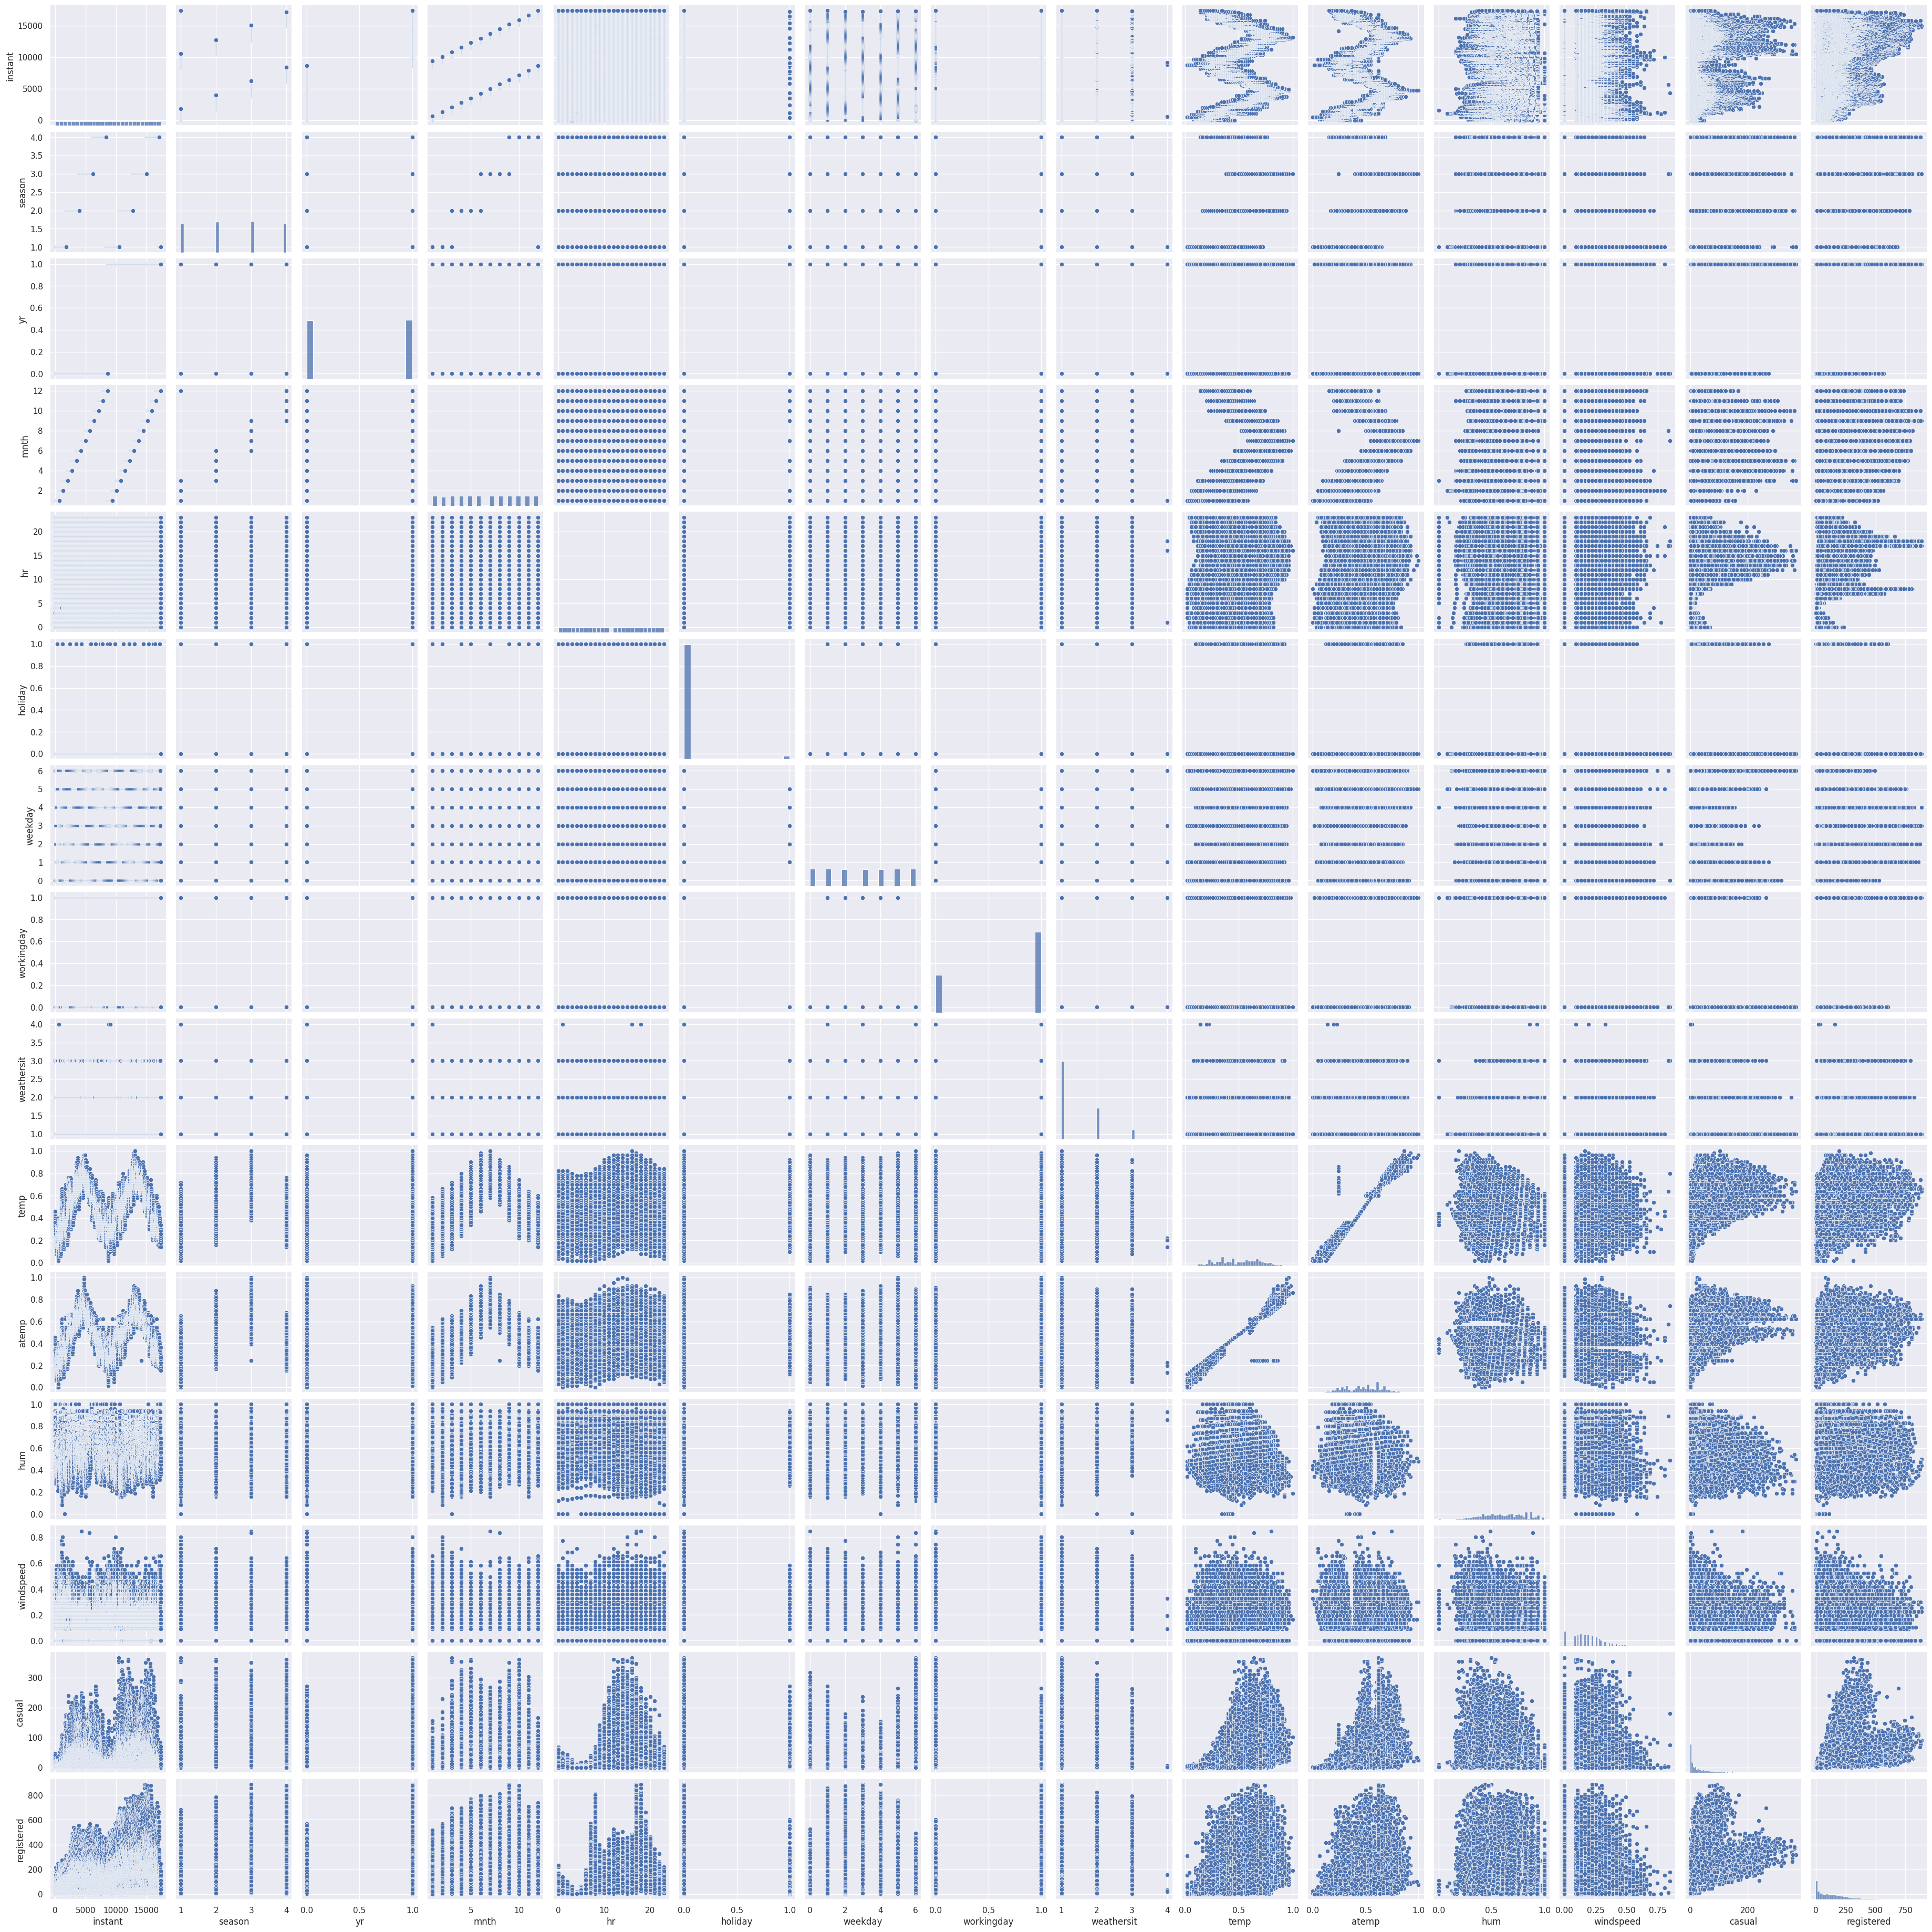

In [87]:
# How are all the predictor variables related to each other?
x = df.drop(['cnt'], axis=1)
y = df['cnt']

sns.pairplot(x)


# How are my selected predictors related to each other and to cnt?
# plot_df = X.copy()
# plot_df['cnt'] = y

# sns.pairplot(plot_df)

In [88]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Normalizing


In [89]:
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [90]:
# Grid Search + Cross Validation

# Grid Search: Test different combinations of hyperparameters, search for
             # the best combination for highest model performance.

# Cross Validation: How well the model generalized, splits training data into
                    # many parts, traines some and validates the other ones.

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Define a parameter grid for hyperparameter tuning
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [ 1, 10],
    'epsilon': [ 1, 10]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(SVR(), param_grid, cv=5, verbose=2)

# Fit the grid search to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   6.1s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   6.7s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   6.0s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   6.4s
[CV] END ......................C=1, epsilon=1, kernel=linear; total time=   6.5s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   9.0s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.0s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.8s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.6s
[CV] END .........................C=1, epsilon=1, kernel=rbf; total time=   8.0s
[CV] END .....................C=1, epsilon=10, kernel=linear; total time=   6.7s
[CV] END .....................C=1, epsilon=10, ke

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [91]:
# XGBoost

from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Fit the model to the training data
xgb_model.fit(X_train, y_train)

# Predict the test data wit hthe fitted model
y_pred_xgb = xgb_model.predict(X_test)


In [92]:
# Linear regression model
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict the test data with the fitted model
y_pred = model.predict(X_test)

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [93]:
# Evaluate XGBoost model
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f"Mean Absolute Error XGBoost: {mae_xgb}")
print(f"Mean Squared Error XGBoost: {mse_xgb}")
print(f"RMSE XGBoost: {rmse_xgb}")
print(f"R-squared XGBoost: {r2_xgb}")

Mean Absolute Error XGBoost: 55.68573760986328
Mean Squared Error XGBoost: 6948.03125
RMSE XGBoost: 83.35485138850648
R-squared XGBoost: 0.7805798053741455


In [94]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred)
mse_linear = mean_squared_error(y_test, y_pred)
r2_linear = r2_score(y_test, y_pred)
rmse_linear = np.sqrt(mse_linear)


print(f"Mean Absolute Error Linear Model: {mae_linear}")
print(f"Mean Squared Error Linear Model: {mse_linear}")
print(f"RMSE Linear: {rmse_linear}")
print(f"R-squared Linear Model: {r2_linear}")

Mean Absolute Error Linear Model: 104.79784665885887
Mean Squared Error Linear Model: 19472.024554634463
RMSE Linear: 139.54219632295624
R-squared Linear Model: 0.38506958435698213


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

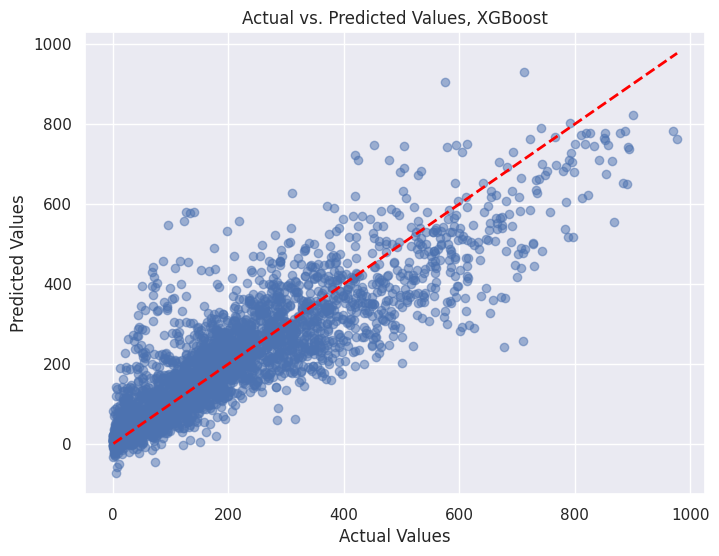

In [95]:
import matplotlib.pyplot as plt
# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values, XGBoost")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()


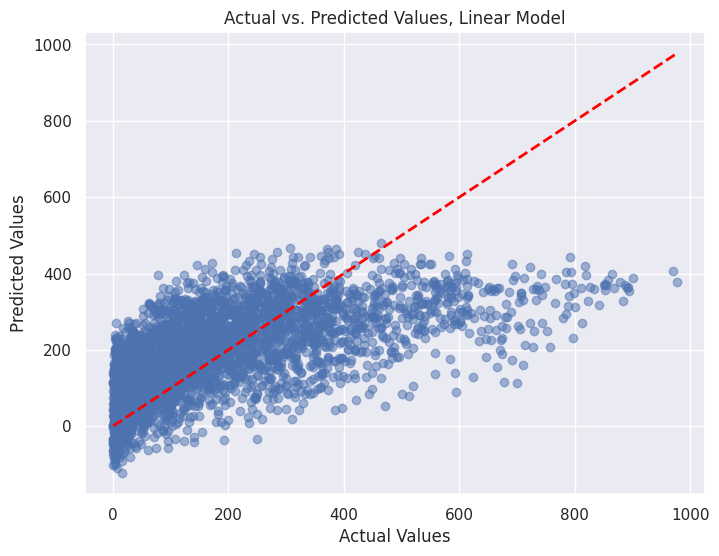

In [96]:
# Actual VS Predicted Values

# y_test contains the actual target values for the test dataset
# y_pred contains the predicted values for the test dataset

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)  # Plot actual vs. predicted values

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values, Linear Model")

# Add a diagonal line for reference (perfect predictions)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', lw=2)

# Show the plot
plt.show()